In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [2]:
import glob
import pandas as pd
import random

# **Read Dataset**

In [3]:
train_df_res = pd.read_csv('drive/MyDrive/Colab Notebooks/Estimates/train_data.csv')
test_df_res = pd.read_csv('drive/MyDrive/Colab Notebooks/Estimates/test_df_res.csv')

In [4]:
# Multiplying risk factor by 100 to make it an integer

In [5]:
test_df_res["Risk_factor_int"] = (test_df_res["Risk_factor"]*100).astype(int)

In [6]:
train_df_res["Risk_factor_int"] = (train_df_res["Risk_factor"]*100).astype(int)

In [7]:
test_df_res.shape

(644, 22)

In [8]:
train_df_res.shape

(5791, 22)

In [9]:
test_df_res.head(3)

,Unnamed: 0.1,Unnamed: 0,Task_name,Task_description,Task_label,Task_priority,Sprint_number,Planned_estimate,Actual_estimate,Optimistic,...,Weighted_average,Standard_deviation,Risk_factor,Standard_confidence,High_confidence,Higher_confidence,Highest_confidence,Final_estimate,Variance,Risk_factor_int
0,2436,2262,[New Containers] Remove input/process dotted l...,Right now the flow container has a dashed line...,EST_BE,Medium,INT Sprint 1,16,16,15,...,15.83,0.17,0.01,15.83,15.92,16.05,16.23,15,6561,1
1,3361,3187,Studio support for new OAuth configuration,"As a Studio user, I will like to have support ...",EST_BE,Medium,INT Sprint 1,4,5,3,...,3.83,0.17,0.04,3.83,3.92,4.05,4.23,3,441,4
2,233,59,"migrate items from 562 get error dialog popup,...","1. start 562 tac, on configuration page select...",EST_BE,Medium,INT Sprint 1,4,4,3,...,4.00,0.33,0.08,4.00,4.17,4.42,4.77,4,729,8


## **One Hot Encoding**

In [10]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

Features

In [11]:
#Task_label
tl_enc = OneHotEncoder(sparse=False, handle_unknown='ignore')
tl_train = train_df_res["Task_label"].to_numpy().reshape(-1,1)
tl_test = test_df_res["Task_label"].to_numpy().reshape(-1,1)
tl_enc.fit(tl_train)
len_tl_enc = tl_enc.categories_[0].shape
print(len_tl_enc)

tl_train = tl_enc.transform(tl_train)
tl_test = tl_enc.transform(tl_test)
print(tl_train.shape, tl_test.shape)

(4,)
(5791, 4) (644, 4)


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [12]:
#Planned_estimate
pe_enc = OneHotEncoder(sparse=False, handle_unknown='ignore')
pe_train = train_df_res["Planned_estimate"].to_numpy().reshape(-1,1)
pe_test = test_df_res["Planned_estimate"].to_numpy().reshape(-1,1)
pe_enc.fit(pe_train)
len_pe_enc = pe_enc.categories_[0].shape
print(len_pe_enc)

pe_train = pe_enc.transform(pe_train)
pe_test = pe_enc.transform(pe_test)
print(pe_train.shape, pe_test.shape)

(15,)
(5791, 15) (644, 15)


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [13]:
#Final_estimate
fe_enc = OneHotEncoder(sparse=False, handle_unknown='ignore')
fe_train = train_df_res["Final_estimate"].to_numpy().reshape(-1,1)
fe_test = test_df_res["Final_estimate"].to_numpy().reshape(-1,1)
fe_enc.fit(fe_train)
len_fe_enc = fe_enc.categories_[0].shape
print(len_fe_enc)

fe_train = fe_enc.transform(fe_train)
fe_test = fe_enc.transform(fe_test)
print(fe_train.shape, fe_test.shape)

(28,)
(5791, 28) (644, 28)


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [14]:
#Optimistic_estimate
oe_enc = OneHotEncoder(sparse=False, handle_unknown='ignore')
oe_train = train_df_res["Optimistic"].to_numpy().reshape(-1,1)
oe_test = test_df_res["Optimistic"].to_numpy().reshape(-1,1)
oe_enc.fit(oe_train)
len_oe_enc = oe_enc.categories_[0].shape
print(len_oe_enc)

oe_train = oe_enc.transform(oe_train)
oe_test = oe_enc.transform(oe_test)
print(oe_train.shape, oe_test.shape)

(23,)
(5791, 23) (644, 23)


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [15]:
#Most_likely_estimate
mle_enc = OneHotEncoder(sparse=False, handle_unknown='ignore')
mle_train = train_df_res["Most_likely"].to_numpy().reshape(-1,1)
mle_test = test_df_res["Most_likely"].to_numpy().reshape(-1,1)
mle_enc.fit(mle_train)
len_mle_enc = mle_enc.categories_[0].shape
print(len_mle_enc)

mle_train = mle_enc.transform(mle_train)
mle_test = mle_enc.transform(mle_test)
print(mle_train.shape, mle_test.shape)

(22,)
(5791, 22) (644, 22)


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [16]:
#Pessimestic_Estimate
pes_enc = OneHotEncoder(sparse=False, handle_unknown='ignore')
pes_train = train_df_res["Pessimistic"].to_numpy().reshape(-1,1)
pes_test = test_df_res["Pessimistic"].to_numpy().reshape(-1,1)
pes_enc.fit(pes_train)
len_pes_enc = pes_enc.categories_[0].shape
print(len_pes_enc)

pes_train = pes_enc.transform(pes_train)
pes_test = pes_enc.transform(pes_test)
print(pes_train.shape, pes_test.shape)

(29,)
(5791, 29) (644, 29)


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [17]:
#Risk_factor_int
rfi_enc = OneHotEncoder(sparse=False, handle_unknown='ignore')
rfi_train = train_df_res["Risk_factor_int"].to_numpy().reshape(-1,1)
rfi_test = test_df_res["Risk_factor_int"].to_numpy().reshape(-1,1)
rfi_enc.fit(rfi_train)
len_rfi_enc = rfi_enc.categories_[0].shape
print(len_rfi_enc)

rfi_train = rfi_enc.transform(rfi_train)
rfi_test = rfi_enc.transform(rfi_test)
print(rfi_train.shape, rfi_test.shape)

(11,)
(5791, 11) (644, 11)


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


Label

In [18]:
#Actual_estimate
ae_enc = OneHotEncoder(sparse=False, handle_unknown='ignore')
ae_train = train_df_res["Actual_estimate"].to_numpy().reshape(-1,1)
ae_test = test_df_res["Actual_estimate"].to_numpy().reshape(-1,1)
ae_enc.fit(ae_train)
len_ae_enc = ae_enc.categories_[0].shape
print(len_ae_enc)

ae_train = ae_enc.transform(ae_train)
ae_test = ae_enc.transform(ae_test)
print(ae_train.shape, ae_test.shape)

(26,)
(5791, 26) (644, 26)


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


## **Gpt-2 tokenizer & pre-trained model**

In [19]:
import tensorflow as tf

In [20]:
from transformers import GPT2Tokenizer, TFGPT2Model

In [21]:
class GPT:
    def __init__(self):
        self.tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
        self.model = TFGPT2Model.from_pretrained('gpt2')

    def inp_vector(self, inp):
        encoded_inp = self.tokenizer(inp, return_tensors='tf')
        out = self.model(encoded_inp)
        vector = out[0].numpy()[0]
        return np.mean(vector, axis=0)

    def vectors(self, inps):
        feat_vectors = []
        for i in inps:
            if type(i) != 'str':
                i = "NA"
            feat_vectors.append(self.inp_vector(i))
        return np.array(feat_vectors)

gpt_model = GPT()

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:72: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

All PyTorch model weights were used when initializing TFGPT2Model.

All the weights of TFGPT2Model were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFGPT2Model for predictions without further training.


## **Features Encoding**

In [ ]:
# No need to calculate embeddings again if dataset is not changed. Load embeddings from below

Task Name

In [ ]:
# training embeddings
# tn_train = gpt_model.vectors(train_df_res["Task_name"])
# np.save('../drive/MyDrive/Colab Notebooks/Estimates/task_name_train.npy', tn_train)
# print(type(tn_train))
# print(tn_train.shape)

In [ ]:
# testing embeddings
# tn_test = gpt_model.vectors(test_df_res["Task_name"])
# np.save('../drive/MyDrive/Colab Notebooks/Estimates/task_name_test.npy', tn_test)
# print(type(tn_test))
# print(tn_test.shape)

Task description

In [ ]:
# training embeddings
# td_train = gpt_model.vectors(train_df_res["Task_description"])
# np.save('../drive/MyDrive/Colab Notebooks/Estimates/task_desc_train.npy', td_train)
# print(type(td_train))
# print(td_train.shape)

In [ ]:
# testing embeddings
# td_test = gpt_model.vectors(test_df_res["Task_description"])
# np.save('../drive/MyDrive/Colab Notebooks/Estimates/task_desc_test.npy', td_test)
# print(type(td_test))
# print(td_test.shape)

## Load features

In [ ]:
# Use this one

In [22]:
# Load feature encodings - Task name, task description, task label, planned estimate & final estimate
tn_train = np.load('drive/MyDrive/Colab Notebooks/Estimates/task_name_train.npy')
tn_test= np.load('drive/MyDrive/Colab Notebooks/Estimates/task_name_test.npy')

td_train = np.load('drive/MyDrive/Colab Notebooks/Estimates/task_desc_train.npy')
td_test = np.load('drive/MyDrive/Colab Notebooks/Estimates/task_desc_test.npy')

In [23]:
tn_train.shape

(5791, 768)

In [29]:
td_train.shape


(5791, 768)

In [30]:
td_test.shape

(644, 768)

In [31]:
tn_test.shape

(644, 768)

## **Define NN Architecture**

In [32]:
# Branch-1 Task name
inp1 = tf.keras.Input(shape=(768,), dtype=tf.int32, name="input_layer_1")
lay1 = tf.keras.layers.Dense(128, activation='relu')(inp1)

# Branch-2 Task description
inp2 = tf.keras.Input(shape=(768,), dtype=tf.int32, name="input_layer_2")
lay2 = tf.keras.layers.Dense(128, activation='relu')(inp2)

# Branch-3 Task label
inp3 = tf.keras.Input(shape=(4,), dtype=tf.int32, name="input_layer_3")
lay3 = tf.keras.layers.Dense(4, activation='relu')(inp3)

# Branch-4 Planned estimate
inp4 = tf.keras.Input(shape=(15,), dtype=tf.int32, name="input_layer_4")
lay4 = tf.keras.layers.Dense(16, activation='relu')(inp4)

# Branch-5 Final estimate
inp5 = tf.keras.Input(shape=(28,), dtype=tf.int32, name="input_layer_5")
lay5 = tf.keras.layers.Dense(32, activation='relu')(inp5)

# Branch-6 Risk Factor multiplied by 100
inp6 = tf.keras.Input(shape=(11,), dtype=tf.int32, name="input_layer_6")
lay6 = tf.keras.layers.Dense(16, activation='relu')(inp6)

# Branch-7 Optimistic estimate
inp7 = tf.keras.Input(shape=(23,), dtype=tf.int32, name="input_layer_7")
lay7 = tf.keras.layers.Dense(32, activation='relu')(inp7)

# Branch-8 Most Likely estimate
inp8 = tf.keras.Input(shape=(22,), dtype=tf.int32, name="input_layer_8")
lay8 = tf.keras.layers.Dense(32, activation='relu')(inp8)

# Branch-9 Pessimistic estimate
inp9 = tf.keras.Input(shape=(29,), dtype=tf.int32, name="input_layer_9")
lay9 = tf.keras.layers.Dense(32, activation='relu')(inp9)

# Concatenate Branch
out = tf.keras.layers.Concatenate()([lay1, lay2, lay3, lay4, lay5, lay6, lay7, lay8, lay9])
out = tf.keras.layers.Dense(384, activation='relu')(out)
out = tf.keras.layers.Dense(128, activation='relu')(out)
out = tf.keras.layers.Dense(26, activation='softmax')(out)

model = tf.keras.models.Model(inputs=[inp1, inp2, inp3, inp4, inp5, inp6, inp7, inp8, inp9], outputs=out)

In [33]:
model.compile(tf.keras.optimizers.Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_layer_1 (InputLayer)  [(None, 768)]                0         []                            
                                                                                                  
 input_layer_2 (InputLayer)  [(None, 768)]                0         []                            
                                                                                                  
 input_layer_3 (InputLayer)  [(None, 4)]                  0         []                            
                                                                                                  
 input_layer_4 (InputLayer)  [(None, 15)]                 0         []                            
                                                                                            

In [34]:
checkpoint = tf.keras.callbacks.ModelCheckpoint('drive/MyDrive/Colab Notebooks/Estimates/Model5/model5.h5', monitor='loss', save_best_only=True, verbose=1)

## **Model Training**

In [35]:
train_sh = model.fit(
    [tn_train, td_train, tl_train, pe_train, fe_train, rfi_train, oe_train, mle_train, pes_train], ae_train,
    epochs=100,
    callbacks=[checkpoint],
    validation_data=([tn_test, td_test, tl_test, pe_test, fe_test, rfi_test, oe_test, mle_test, pes_test], ae_test),
    batch_size=32,
    verbose=1
)

Epoch 1/100
176/181 [============================>.] - ETA: 0s - loss: 1.5167 - accuracy: 0.4142
Epoch 1: loss improved from inf to 1.50151, saving model to drive/MyDrive/Colab Notebooks/Estimates/Model5/model5.h5
181/181 [==============================] - 5s 13ms/step - loss: 1.5015 - accuracy: 0.4184 - val_loss: 0.9775 - val_accuracy: 0.4814
Epoch 2/100
  1/181 [..............................] - ETA: 2s - loss: 0.9704 - accuracy: 0.3438

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


179/181 [============================>.] - ETA: 0s - loss: 0.8743 - accuracy: 0.4873
Epoch 2: loss improved from 1.50151 to 0.87445, saving model to drive/MyDrive/Colab Notebooks/Estimates/Model5/model5.h5
181/181 [==============================] - 2s 10ms/step - loss: 0.8744 - accuracy: 0.4873 - val_loss: 0.8489 - val_accuracy: 0.5171
Epoch 3/100
175/181 [============================>.] - ETA: 0s - loss: 0.8056 - accuracy: 0.5084
Epoch 3: loss improved from 0.87445 to 0.80582, saving model to drive/MyDrive/Colab Notebooks/Estimates/Model5/model5.h5
181/181 [==============================] - 2s 10ms/step - loss: 0.8058 - accuracy: 0.5091 - val_loss: 0.7887 - val_accuracy: 0.5186
Epoch 4/100
181/181 [==============================] - ETA: 0s - loss: 0.7633 - accuracy: 0.5089
Epoch 4: loss improved from 0.80582 to 0.76329, saving model to drive/MyDrive/Colab Notebooks/Estimates/Model5/model5.h5
181/181 [==============================] - 3s 16ms/step - loss: 0.7633 - accuracy: 0.5089 - va

In [37]:
print(train_sh.history)
model.save('drive/MyDrive/Colab Notebooks/Estimates/Model5/model5.h5')
results = model.evaluate([tn_test, td_test, tl_test, pe_test, fe_test, rfi_test, oe_test, mle_test, pes_test], ae_test, batch_size=16)

predictions = model.predict([tn_test, td_test, tl_test, pe_test, fe_test, rfi_test, oe_test, mle_test, pes_test])

print(predictions.shape)
print(ae_test.shape)

y_actual_label = test_df_res["Actual_estimate"]
y_pred_label = ae_enc.inverse_transform(predictions)
print(y_actual_label.shape, y_pred_label.shape)

test_df_res['Ai_estimate'] = y_pred_label
test_df_res.head(3)

{'loss': [1.5015076398849487, 0.8744490742683411, 0.8058249950408936, 0.7632899880409241, 0.7475754022598267, 0.7371658086776733, 0.7253066897392273, 0.7131375670433044, 0.7085978388786316, 0.7011968493461609, 0.6942271590232849, 0.6954235434532166, 0.6919319033622742, 0.6918119788169861, 0.6858657002449036, 0.68558269739151, 0.6859502196311951, 0.6815438866615295, 0.6800907254219055, 0.6808831691741943, 0.679620623588562, 0.6771450638771057, 0.675444483757019, 0.6770991683006287, 0.676064670085907, 0.6761173009872437, 0.6734427213668823, 0.6743815541267395, 0.6742904186248779, 0.67376309633255, 0.6752564311027527, 0.6718370318412781, 0.6750488877296448, 0.6724839806556702, 0.6731125116348267, 0.6701216697692871, 0.6715318560600281, 0.6708789467811584, 0.6710616946220398, 0.6704797744750977, 0.6690531373023987, 0.6702630519866943, 0.6703897714614868, 0.6676865220069885, 0.6698853969573975, 0.668691873550415, 0.6685929894447327, 0.6687564849853516, 0.6693800687789917, 0.668232262134552,

,Unnamed: 0.1,Unnamed: 0,Task_name,Task_description,Task_label,Task_priority,Sprint_number,Planned_estimate,Actual_estimate,Optimistic,...,Standard_deviation,Risk_factor,Standard_confidence,High_confidence,Higher_confidence,Highest_confidence,Final_estimate,Variance,Risk_factor_int,Ai_estimate
0,2436,2262,[New Containers] Remove input/process dotted l...,Right now the flow container has a dashed line...,EST_BE,Medium,INT Sprint 1,16,16,15,...,0.17,0.01,15.83,15.92,16.05,16.23,15,6561,1,17
1,3361,3187,Studio support for new OAuth configuration,"As a Studio user, I will like to have support ...",EST_BE,Medium,INT Sprint 1,4,5,3,...,0.17,0.04,3.83,3.92,4.05,4.23,3,441,4,4
2,233,59,"migrate items from 562 get error dialog popup,...","1. start 562 tac, on configuration page select...",EST_BE,Medium,INT Sprint 1,4,4,3,...,0.33,0.08,4.00,4.17,4.42,4.77,4,729,8,4


In [38]:
test_df_res.drop(test_df_res.columns[[0, 1]], axis=1, inplace=True)

In [39]:
test_df_res.head(3)

,Task_name,Task_description,Task_label,Task_priority,Sprint_number,Planned_estimate,Actual_estimate,Optimistic,Most_likely,Pessimistic,...,Standard_deviation,Risk_factor,Standard_confidence,High_confidence,Higher_confidence,Highest_confidence,Final_estimate,Variance,Risk_factor_int,Ai_estimate
0,[New Containers] Remove input/process dotted l...,Right now the flow container has a dashed line...,EST_BE,Medium,INT Sprint 1,16,16,15,16,16,...,0.17,0.01,15.83,15.92,16.05,16.23,15,6561,1,17
1,Studio support for new OAuth configuration,"As a Studio user, I will like to have support ...",EST_BE,Medium,INT Sprint 1,4,5,3,4,4,...,0.17,0.04,3.83,3.92,4.05,4.23,3,441,4,4
2,"migrate items from 562 get error dialog popup,...","1. start 562 tac, on configuration page select...",EST_BE,Medium,INT Sprint 1,4,4,3,4,5,...,0.33,0.08,4.00,4.17,4.42,4.77,4,729,8,4


In [40]:
test_df_res.to_csv('drive/MyDrive/Colab Notebooks/Estimates/Model5/Model5_results.csv')

Text(0, 0.5, 'AI estimate')

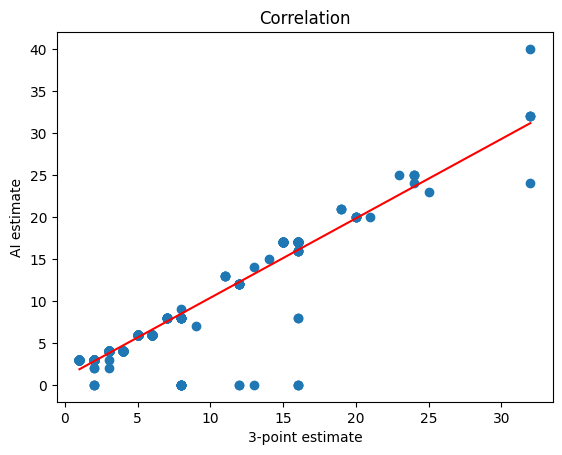

In [41]:
import sklearn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

y = test_df_res['Ai_estimate']
x = test_df_res['Final_estimate']
correlation = y.corr(x)
correlation

# adds the title
plt.title('Correlation')

# plot the data
plt.scatter(x, y)

# fits the best fitting line to the data
plt.plot(np.unique(x),
		np.poly1d(np.polyfit(x, y, 1))
		(np.unique(x)), color='red')

# Labelling axes
plt.xlabel('3-point estimate')
plt.ylabel('AI estimate')

In [ ]:
# prepare testing data

In [42]:
df_test = pd.read_csv('drive/MyDrive/Colab Notebooks/Estimates/test_data.csv')

In [43]:
df_test.shape

(21, 7)

In [ ]:
df_test.head(3)


In [ ]:
import numpy as np

In [ ]:
df_test["Optimistic"] = df_test["Planned_estimate"] + np.random.randint(0, 1, df_test.shape[0])
df_test["Most_likely"] = df_test["Planned_estimate"] + np.random.randint(0, 2, df_test.shape[0])
df_test["Pessimistic"] = df_test["Planned_estimate"] + np.random.randint(0, 3, df_test.shape[0])

In [ ]:
df_test["Weighted_average"] = round(((df_test["Optimistic"] + (4*df_test["Most_likely"]) + df_test["Pessimistic"])/6), 2)
df_test["Standard_deviation"] = round(((df_test["Pessimistic"] - df_test["Optimistic"])/6), 2)
df_test["Risk_factor"] = round((df_test["Standard_deviation"]/df_test["Weighted_average"]), 2)
df_test["Standard_confidence"] = df_test["Weighted_average"]
df_test["High_confidence"] = round((df_test["Weighted_average"] + (0.53 * df_test["Standard_deviation"])), 2)
df_test["Higher_confidence"] = round((df_test["Weighted_average"] + (1.28 * df_test["Standard_deviation"])), 2)
df_test["Highest_confidence"] = round((df_test["Weighted_average"] + (2.33 * df_test["Standard_deviation"])), 2)
df_test["Final_estimate"] = round((df_test["Highest_confidence"]), 1)
df_test["Variance"] = round(((6*df_test["Pessimistic"] - df_test["Optimistic"])**2), 2)
df_test['Final_estimate'] = np.where((df_test['Risk_factor'] >= 0) & (df_test['Risk_factor'] <= 0.05), df_test['Standard_confidence'], df_test['Final_estimate'])
df_test['Final_estimate'] = np.where((df_test['Risk_factor'] > 0.05) & (df_test['Risk_factor'] <= 0.1), df_test['High_confidence'], df_test['Final_estimate'])
df_test['Final_estimate'] = np.where((df_test['Risk_factor'] > 0.1) & (df_test['Risk_factor'] <= 0.15), df_test['Higher_confidence'], df_test['Final_estimate'])
df_test["Final_estimate"] = df_test["Final_estimate"].astype(int)
df_test["Risk_factor_int"] = (df_test["Risk_factor"]*100).astype(int)


In [ ]:
df_test.to_csv('drive/MyDrive/Colab Notebooks/Estimates/Model4/test_data_complete.csv')

In [ ]:
### Start

In [ ]:
# need to change this
df_test = pd.read_csv('drive/MyDrive/Colab Notebooks/Estimates/Model4/test_data_complete.csv')

In [ ]:
df_test.shape

(21, 21)

In [ ]:
df_test.head(3)

,Unnamed: 0,Task_name,Task_description,Task_label,Task_priority,Sprint_number,Planned_estimate,Actual_estimate,Optimistic,Most_likely,...,Weighted_average,Standard_deviation,Risk_factor,Standard_confidence,High_confidence,Higher_confidence,Highest_confidence,Final_estimate,Variance,Risk_factor_int
0,0,Set up JDK and integrate with backend,Setting up the Java Development Kit in the pro...,EST_BE,Medium,ET Sprint 4,16,16,16,17,...,16.83,0.17,0.01,16.83,16.92,17.05,17.23,16,7396,1
1,1,Set up environment and install packages,Setting up Python environment in AWS EC-2 Inst...,EST_INFRA,Medium,ET Sprint 4,4,4,4,5,...,5.00,0.33,0.07,5.00,5.17,5.42,5.77,5,1024,7
2,2,"Create data preprocessing, feature engineering...",Data preprocessing - Data cleaning and transfo...,EST_AI,Medium,ET Sprint 4,8,9,8,9,...,8.67,0.00,0.00,8.67,8.67,8.67,8.67,8,1600,0


In [ ]:
# Testing data encodings
tn_testdata = gpt_model.vectors(df_test["Task_name"])
print(type(tn_testdata))
print(tn_testdata.shape)

td_testdata = gpt_model.vectors(df_test["Task_description"])
print(type(td_testdata))
print(td_testdata.shape)

tl_testdata = df_test["Task_label"].to_numpy().reshape(-1,1)
tl_testdata = tl_enc.transform(tl_testdata)
print(tl_testdata.shape)

pe_testdata = df_test["Planned_estimate"].to_numpy().reshape(-1,1)
pe_testdata = pe_enc.transform(pe_testdata)
print(pe_testdata.shape)

fe_testdata = df_test["Final_estimate"].to_numpy().reshape(-1,1)
fe_testdata = fe_enc.transform(fe_testdata)
print(fe_testdata.shape)

rfi_testdata = df_test["Risk_factor_int"].to_numpy().reshape(-1,1)
rfi_testdata = rfi_enc.transform(rfi_testdata)
print(rfi_testdata.shape)

<class 'numpy.ndarray'>
(21, 768)
<class 'numpy.ndarray'>
(21, 768)
(21, 4)
(21, 15)
(21, 28)
(21, 11)


In [ ]:
import tensorflow as tf

In [ ]:
model4 = tf.keras.models.load_model('drive/MyDrive/Colab Notebooks/Estimates/Model4/model4.h5')
model4.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_layer_1 (InputLayer)  [(None, 768)]                0         []                            
                                                                                                  
 input_layer_2 (InputLayer)  [(None, 768)]                0         []                            
                                                                                                  
 input_layer_3 (InputLayer)  [(None, 4)]                  0         []                            
                                                                                                  
 input_layer_4 (InputLayer)  [(None, 15)]                 0         []                            
                                                                                            

In [ ]:
### Not required

In [ ]:
from sklearn.preprocessing import OneHotEncoder

train_df_res = pd.read_csv('drive/MyDrive/Colab Notebooks/Estimates/train_data.csv')
test_df_res = pd.read_csv('drive/MyDrive/Colab Notebooks/Estimates/test_df_res.csv')

#Actual_estimate
ae_enc = OneHotEncoder(sparse=False, handle_unknown='ignore')
ae_train = train_df_res["Actual_estimate"].to_numpy().reshape(-1,1)
ae_test = test_df_res["Actual_estimate"].to_numpy().reshape(-1,1)
ae_enc.fit(ae_train)
len_ae_enc = ae_enc.categories_[0].shape
print(len_ae_enc)

ae_train = ae_enc.transform(ae_train)
ae_test = ae_enc.transform(ae_test)
print(ae_train.shape, ae_test.shape)

(26,)
(5791, 26) (644, 26)


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [ ]:
ae_testdata = df_test["Actual_estimate"].to_numpy().reshape(-1,1)
ae_testdata = ae_enc.transform(ae_testdata)
print(ae_testdata.shape)

(21, 26)


In [ ]:
predictions = model4.predict([tn_testdata, td_testdata, tl_testdata, pe_testdata, fe_testdata, rfi_testdata])

print(predictions.shape)
print(ae_testdata.shape)

y_actual_label = df_test["Actual_estimate"]
y_pred_label = ae_enc.inverse_transform(predictions)

print(y_actual_label.shape, y_pred_label.shape)

df_test['Ai_estimate'] = y_pred_label

df_test.drop(df_test.columns[0], axis=1, inplace=True)

1/1 [==============================] - 0s 21ms/step
(21, 26)
(21, 26)
(21,) (21, 1)


In [ ]:
df_test.to_csv('drive/MyDrive/Colab Notebooks/Estimates/Model4/Model4_results_testdata.csv')

In [ ]:
df_test.head(3)

,Task_name,Task_description,Task_label,Task_priority,Sprint_number,Planned_estimate,Actual_estimate,Optimistic,Most_likely,Pessimistic,...,Standard_deviation,Risk_factor,Standard_confidence,High_confidence,Higher_confidence,Highest_confidence,Final_estimate,Variance,Risk_factor_int,Ai_estimate
0,Set up JDK and integrate with backend,Setting up the Java Development Kit in the pro...,EST_BE,Medium,ET Sprint 4,16,16,16,17,17,...,0.17,0.01,16.83,16.92,17.05,17.23,16,7396,1,16
1,Set up environment and install packages,Setting up Python environment in AWS EC-2 Inst...,EST_INFRA,Medium,ET Sprint 4,4,4,4,5,6,...,0.33,0.07,5.00,5.17,5.42,5.77,5,1024,7,0
2,"Create data preprocessing, feature engineering...",Data preprocessing - Data cleaning and transfo...,EST_AI,Medium,ET Sprint 4,8,9,8,9,8,...,0.00,0.00,8.67,8.67,8.67,8.67,8,1600,0,8


Text(0, 0.5, 'AI estimate')

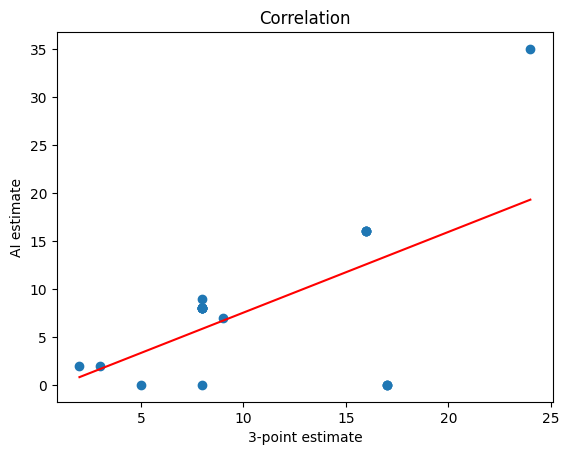

In [ ]:
import sklearn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

y = df_test['Ai_estimate']
x = df_test['Final_estimate']
correlation = y.corr(x)
correlation

# adds the title
plt.title('Correlation')

# plot the data
plt.scatter(x, y)

# fits the best fitting line to the data
plt.plot(np.unique(x),
		np.poly1d(np.polyfit(x, y, 1))
		(np.unique(x)), color='red')

# Labelling axes
plt.xlabel('3-point estimate')
plt.ylabel('AI estimate')

Text(0, 0.5, 'AI estimate')

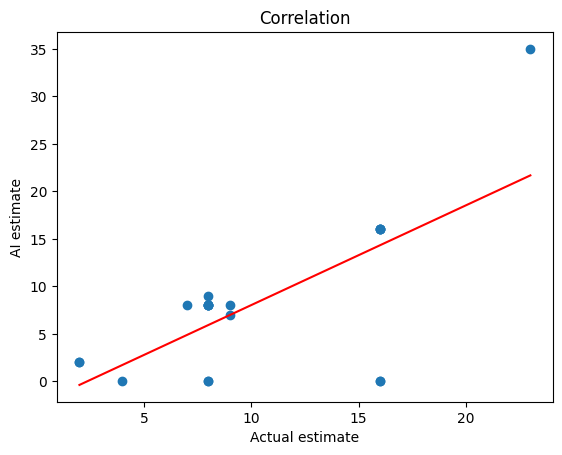

In [ ]:
import sklearn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

y = df_test['Ai_estimate']
x = df_test['Actual_estimate']
correlation = y.corr(x)
correlation

# adds the title
plt.title('Correlation')

# plot the data
plt.scatter(x, y)

# fits the best fitting line to the data
plt.plot(np.unique(x),
		np.poly1d(np.polyfit(x, y, 1))
		(np.unique(x)), color='red')

# Labelling axes
plt.xlabel('Actual estimate')
plt.ylabel('AI estimate')